In [9]:
# Conda dependencies are listed under environment.yml
import copy
import os
from datetime import datetime, timedelta
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.dates import num2date, date2num
import matplotlib.gridspec as gridspec
import numpy as np
import pickle
import scipy.io
from scipy import stats
import scipy
import warnings
from sunpy.time import parse_time
import pandas as pd
import matplotlib.dates as mdates
import astropy.units as u
from scipy.optimize import curve_fit, least_squares, minimize
import time
import numba
from numba import jit
from sunpy.coordinates import HeliographicStonyhurst, HeliocentricEarthEcliptic
import urllib
import multiprocess as mp
from scipy.stats import gaussian_kde
from scipy.stats import norm

import seaborn as sns

warnings.filterwarnings('ignore') # some numpy mean-of-empty-slice runtime warnings

sns.set_style('whitegrid', {'xtick.bottom': False, 'grid.color': 'gainsboro'})
sns.set_context('paper')

c0 = 'xkcd:black'
c1 = 'xkcd:magenta'
c2 = 'xkcd:orange'
c3 = 'xkcd:azure'
c4 = 'xkcd:green'

data_path = 'data/new/'

In [ ]:
beacon=True
use_plasma=True

print('Loading')

if beacon:
    if use_plasma:
        data1 = pickle.load(open(data_path+'sta_symh_final_beacon_plasma.p', 'rb'))
        [indices_dst_sta, indices_dst_wind, indices_dst_omni, indices_obs_sta, indices_obs_omni, indices_l1_sta] = pickle.load( open(data_path+'indices_geomagnetic_storms_beacon_plasma.p', 'rb'))
    else: 
        data1 = pickle.load(open(data_path+'sta_symh_final_beacon.p', 'rb'))
        [indices_dst_sta, indices_dst_wind, indices_dst_omni, indices_obs_sta, indices_obs_omni, indices_l1_sta] = pickle.load( open(data_path+'indices_geomagnetic_storms_beacon.p', 'rb'))
print('...')
data_l1 = pickle.load(open(data_path+'symh_l1_fin.p', 'rb'))
print('...')
time_ensemble = pickle.load(open(data_path+'time_ensemble.p', 'rb'))
print('...')
#symh_ensemble = pickle.load(open('symh_ensemble_20250806.p', 'rb'))
omni_input = pickle.load(open(data_path+'omni_20221111_20240604.p', 'rb'))
print('...')
times = pd.read_csv(data_path+'events_times_new.csv', header=0, delimiter=';')
times.sta_start = pd.to_datetime(times.sta_start, format='%Y-%m-%dT%H:%MZ')
times.sta_end = pd.to_datetime(times.sta_end, format='%Y-%m-%dT%H:%MZ')
times.l1_start = pd.to_datetime(times.l1_start, format='%Y-%m-%dT%H:%MZ')
times.l1_end = pd.to_datetime(times.l1_end, format='%Y-%m-%dT%H:%MZ')
print('done')

Loading


In [7]:
std = data1['symh_err'][0]/2.
x = np.linspace(-3*std,3*std,1000)
y = norm(loc=data1['symh'][0], scale=std).pdf(data1['symh'][0]+x)
y_fin = y/np.nanmax(y,axis=0)

#print(y_fin)
#plt.figure(2, figsize=(12,8))



#kde_symh = gaussian_kde(symh_ensemble[index])
#y_vals_symh = np.linspace(np.min(symh_ensemble[index]), np.max(symh_ensemble[index]), 250)
#x_vals_symh = kde_symh(y_vals_symh)
#x_vals_symh /= np.max(x_vals_symh)  # normalize
#ax2.plot_date([0,1.01], [current_symh,current_symh],'--k', lw=1., alpha=0.6)

In [6]:
mask = np.isin(indices_dst_omni, indices_obs_omni)
indices_omni_miss = indices_dst_omni[mask==False]
indices_omni_hit = indices_dst_omni[mask==True]
time_storm_hit_omni = omni_input['time'][indices_omni_hit]
time_storm_miss_omni = omni_input.time[indices_omni_miss]

time_storm_omni = omni_input.time[indices_dst_omni]
time_storm_sta = data1['time'][indices_dst_sta]

mask_alarm = np.isin(indices_dst_sta, indices_obs_sta)
indices_false_alarm = indices_dst_sta[mask_alarm==False]
indices_sta_hit = indices_dst_sta[mask_alarm==True]
time_false_alarm = data1['time'][indices_false_alarm] 
time_storm_hit = data1['time'][indices_obs_sta]


#print(time_storm_hit)
#print(len(time_storm_omni), len(time_storm_hit), len(time_storm_miss))


#print('time missed geomagnetic storms: ', time_storm_miss)
#print('time hit geomagnetic storms: ', time_storm_hit)

#time_hit=[data1['time'][data1['time']==i] for i in time_storm_hit]
#symh_hit=[data1['symh'][data1['time']==i] for i in time_storm_hit]
time_hit_omni=[omni_input['time'][omni_input['time']==i] for i in time_storm_hit_omni]
symh_hit_omni=[omni_input['symh'][omni_input['time']==i] for i in time_storm_hit_omni]
time_hit_sta=[data1['time'][data1['time']==i] for i in time_storm_hit]
symh_hit_sta=[data1['symh'][data1['time']==i] for i in time_storm_hit]
time_miss_omni=[omni_input['time'][omni_input['time']==i] for i in time_storm_miss_omni]
symh_miss_omni=[omni_input['symh'][omni_input['time']==i] for i in time_storm_miss_omni]
time_sta=[data1['time'][data1['time']==i] for i in time_storm_sta]
symh_sta=[data1['symh'][data1['time']==i] for i in time_storm_sta]
time_false_alarm=[data1['time'][data1['time']==i] for i in time_false_alarm]
symh_false_alarm=[data1['symh'][data1['time']==i] for i in time_false_alarm]

#time_omni=[omni_input['time'][omni_input['time']==i] for i in time_storm_omni]
#symh_omni=[omni_input['symh'][omni_input['time']==i] for i in time_storm_omni]

#print(time_hit_omni)

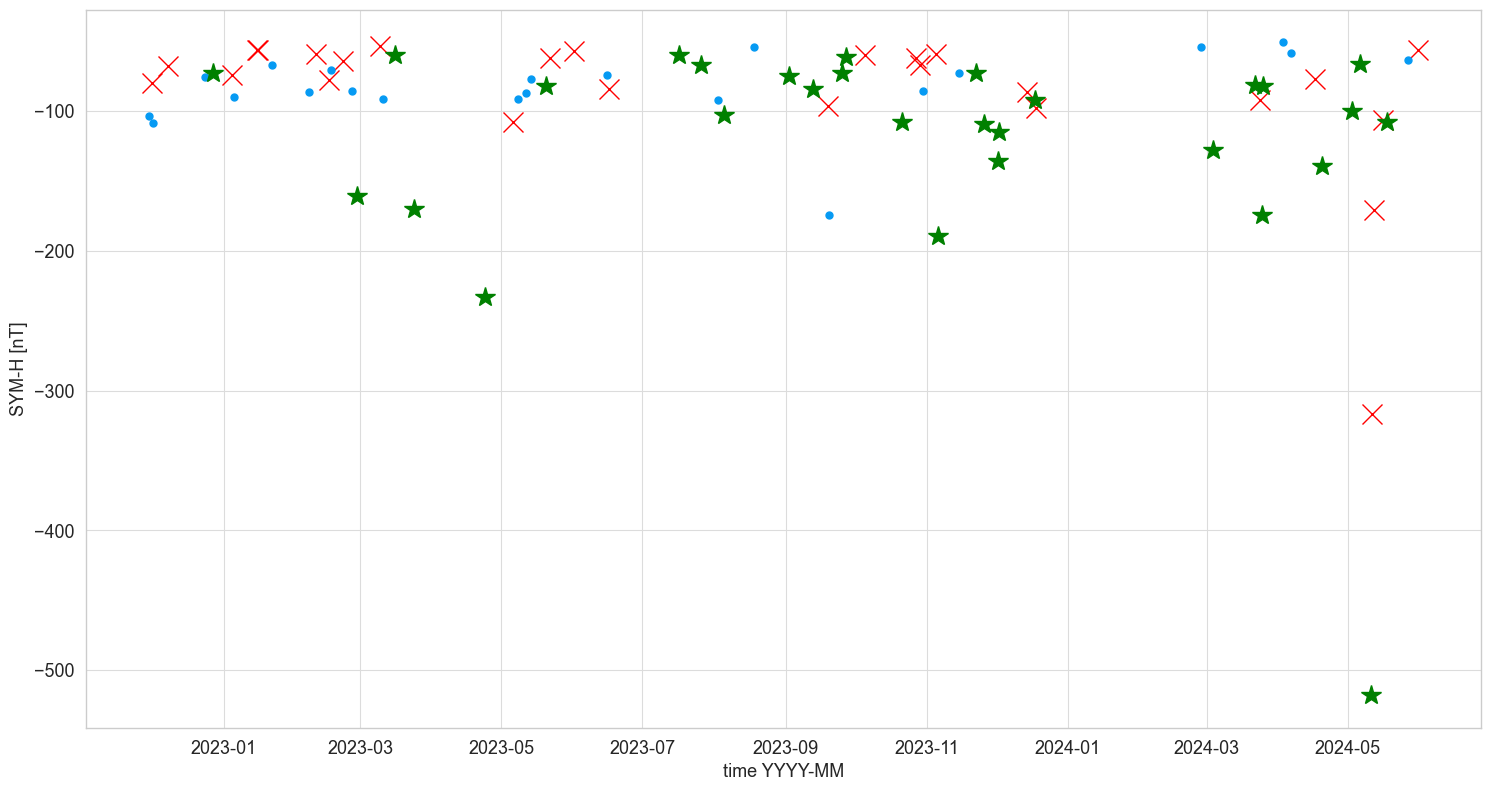

In [7]:
plt.figure(1, figsize=(15,8))
plt.plot(time_miss_omni, symh_miss_omni, marker='x', ms=15, color='red', ls=' ')
plt.plot(time_false_alarm, symh_false_alarm, marker='o', ms=5, color=c3, ls=' ')
plt.plot(time_hit_omni, symh_hit_omni, marker='*', ms=15, color='green', ls=' ')
plt.xlabel('time YYYY-MM',fontsize=13)
plt.ylabel('SYM-H [nT]',fontsize=13)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.tight_layout()
#plt.savefig('hits_misses_false_alarms_beacon_plasma.png')

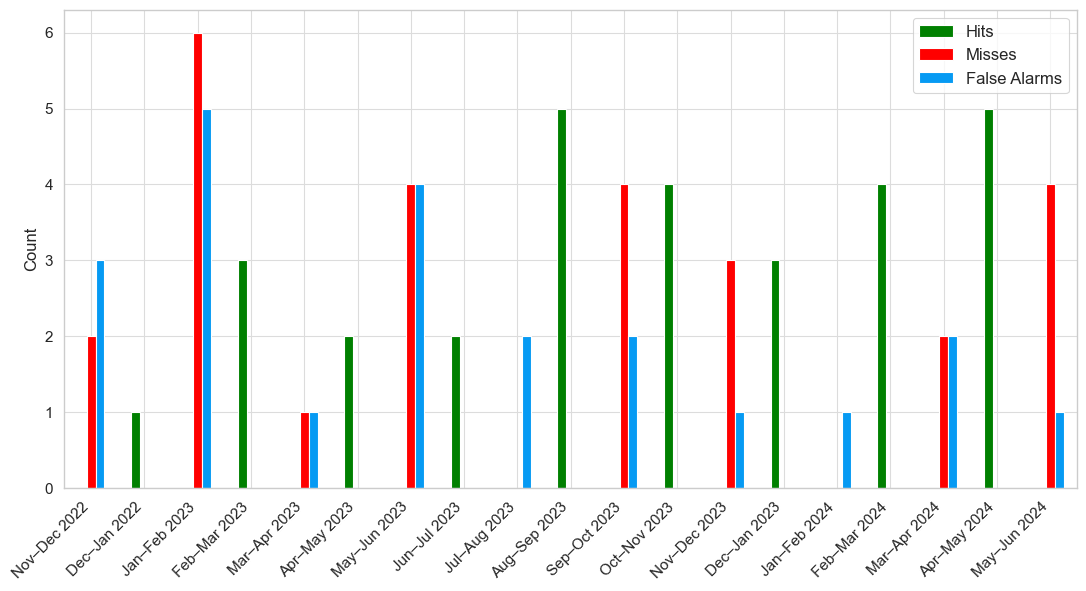

In [15]:
# Turn both into Series
hits = pd.Series([dt[0] for dt in time_hit_omni])
misses = pd.Series([dt[0] for dt in time_miss_omni])
false = pd.Series([dt[0] for dt in time_false_alarm])

# Convert to datetime index
hit_counts = hits.value_counts().sort_index()
hit_counts.index = pd.to_datetime(hit_counts.index)

miss_counts = misses.value_counts().sort_index()
miss_counts.index = pd.to_datetime(miss_counts.index)

false_counts = false.value_counts().sort_index()
false_counts.index = pd.to_datetime(false_counts.index)

# Resample into 2-month bins (anchored at start of Jan, Mar, May, ...)
hit_binned = hit_counts.resample("2MS").sum()
miss_binned = miss_counts.resample("2MS").sum()
false_binned = false_counts.resample("2MS").sum()

# Combine into one DataFrame
df = pd.DataFrame({"Hits": hit_binned, "Misses": miss_binned, "False Alarms": false_binned}).fillna(0)

# --- Make custom labels ---
labels = []
for d in df.index:
    start_month = d.strftime("%b")       # Jan, Mar, May, ...
    end_month = (d + pd.DateOffset(months=1)).strftime("%b")  # next month
    year = d.strftime("%Y")
    labels.append(f"{start_month}–{end_month} {year}")

# --- Plot with custom labels ---
#fig, ax = plt.subplots(figsize=(10,10))

ax = df.plot(kind="bar", color=["green", "red", c3], figsize=(11,6))

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=11)
ax.tick_params('y', labelsize=11)

#ax.set_xlabel("2-Month Interval", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
#ax.set_title("2-Month Peaks: Hits vs Misses", fontsize=14)
ax.legend(fontsize=12, loc="upper right")

plt.tight_layout()
plt.savefig('hits_misses_false_alarms_bar_plot_beacon_plasma.png')

In [16]:
plot_monthly = False

if plot_monthly:
    # Count per month
    hit_counts = hits.groupby(hits.dt.to_period("M")).size()
    miss_counts = misses.groupby(misses.dt.to_period("M")).size()
    false_alarm_counts = false_alarms.groupby(false_alarms.dt.to_period("M")).size()

    # Reindex so both cover the same full range
    all_months = pd.period_range(omni_df['time'].min().to_period("M"), dates.max().to_period("M"), freq="M")
    hit_counts = hit_counts.reindex(all_months, fill_value=0)
    miss_counts = miss_counts.reindex(all_months, fill_value=0)
    false_alarm_counts = false_alarm_counts.reindex(all_months, fill_value=0)

    # Combine into one DataFrame
    df = pd.DataFrame({"Hits": hit_counts, "Misses": miss_counts, "False Alarms": false_alarm_counts})

    # Plot side by side bars
    df.plot(kind="bar", rot=45, ylabel="Count", title="Monthly Peaks: Hits vs Misses")
    plt.tight_layout()
    plt.show()

In [17]:
def make_frame(k, make_movie=False):
    '''
    loop each frame in multiprocessing
    '''
    

    fig=plt.figure(1, figsize=(19.2,10.8), dpi=100) #full hd
    #fig = plt.figure(figsize=(15,10), dpi=100)
    
    # Grid: 3 rows, 3 columns, with specific placement
    gs = gridspec.GridSpec(3, 3, figure=fig, height_ratios=[1, 0.05, 2], width_ratios=[20, 0.3, 2], hspace=0.01, wspace=0.05)

    # Top density (time KDE)
    ax0 = fig.add_subplot(gs[0, :2])

    # Bottom SYM-H time series
    ax1 = fig.add_subplot(gs[2, :2])

    # Right SYM-H KDE
    ax2 = fig.add_subplot(gs[2, -1], sharey=ax1)
    
    
    #fig=plt.figure(1, figsize=(19.2*2,10.8*2), dpi=100) #4k


    frame_time_str=str(mdates.num2date(frame_time_num+k*res_in_days))
    
    time_now=frame_time_num+k*res_in_days
    time_now_date = t_start + timedelta(days=k*res_in_days)
    
    #print(index)
    

    
    #ensemble_at_time_now = time_ensemble[index]
    #error_time = (ensemble_at_time_now-np.median(ensemble_at_time_now))/24./3600

    #print(mdates.num2date(time_now+error_time))
    
    #------------------------------------------------ IN SITU DATA ------------------------------------------------------
  
    #cut data for plot window so faster
    
    if data1['time'][-1] > time_now_date+timedelta(days=days_window):
        dindex1=np.where(data1['time'] > time_now_date-timedelta(days=days_window))[0][0]
        dindex2=np.where(data1['time'] > time_now_date+timedelta(days=days_window))[0][0]
        #use last index   oindex2=np.size(o1)-1
        data=data1[dindex1:dindex2] 
        
    if data_l1['time'][-1] > time_now_date+timedelta(days=days_window):
        lindex1=np.where(data_l1['time'] > time_now_date-timedelta(days=days_window))[0][0]
        lindex2=np.where(data_l1['time'] > time_now_date+timedelta(days=days_window))[0][0]
        #use last index   oindex2=np.size(o1)-1
        l1=data_l1[lindex1:lindex2] 
        
    if omni_input['time'][-1] > time_now_date+timedelta(days=days_window):
        oindex1=np.where(omni_input['time'] > time_now_date-timedelta(days=days_window))[0][0]
        oindex2=np.where(omni_input['time'] > time_now_date+timedelta(days=days_window))[0][0]
        #use last index   oindex2=np.size(o1)-1
        omni=omni_input[oindex1:oindex2] 
        
    index = np.where(data['time']==time_now_date)[0][0]
    current_symh = data['symh'][index]
        
    days_dist = 2
    
    # Compute KDE manually
    std = data['time_err'][index]
    x_vals = np.linspace(-3*std,3*std,100)
    y_vals = norm(loc=time_now, scale=std/24.).pdf(time_now+x_vals/24.)
    #y_fin = y/np.nanmax(y,axis=0)
    
    #kde = gaussian_kde(time_now+error_time)
    #x_vals = np.linspace(time_now - days_window, time_now + days_window, 500)
    #y_vals = kde(x_vals)

    # Normalize to max = 1
    y_vals /= np.nanmax(y_vals)
    
    

    #with sns.axes_style('white', {'axes.edgecolor': 'none'}):
    #ax0 = plt.subplot2grid((3,1), (0,0))
    #sns.kdeplot(time_now+error_time, ax=ax0,  color=c3, linewidth=2, fill=True)
    ax0.fill_between(time_now+x_vals/24., y_vals, color=c3, alpha=0.6)
    ax0.plot(time_now+x_vals/24., y_vals, color=c3, linewidth=2)
    ax0.plot_date([time_now,time_now], [0,2],'--', lw=1., alpha=0.9, color=c0)


    ax0.set_xlim(time_now-days_window,time_now+days_window)
    ax0.set_ylim(0.01,1.01)
    ax0.set_xticklabels([])
    ax0.set_yticklabels([])
    plt.tick_params( axis='x', labelbottom='off')
    #plt.yticks(fontsize=fsize-1)

    
    if np.size(data)>0:
        
        #ax1 = plt.subplot2grid((3,1), (1,0), rowspan=2)
        #ax1.set_ylim(np.min(data['symh'])-20, np.max(data['symh'])+20)
        ax1.set_ylabel('SYM-H [nT]',fontsize=fsize)
        ax1.xaxis.set_major_formatter( matplotlib.dates.DateFormatter('%Y-%b-%d') )
        ax1.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(days_dist))
        ax1.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(days_dist/6))
        ax1.tick_params(axis='x', labelsize=15)
        ax1.tick_params(axis='y', labelsize=13)

        for i in range(len(times.l1_start)):
            ax1.fill_betweenx([-1000,200], times.l1_start[i], times.l1_end[i], color=c2, alpha=0.2)
        
        ax1.plot_date(omni['time'],omni['symh'],'-',c=c0,label='SYM-H obs.',linewidth=1)
        ax1.plot_date(l1['time'],l1['symh'],'-',c=c2,label='SYM-H L1',linewidth=1)
        ax1.plot_date(data['time'],data['symh'],'-',c=c3,label='SYM-H STEREO-A',linewidth=1)
        
        ax1.plot_date([time_now-days_window,time_now+days_window], [current_symh,current_symh],'--k', lw=1., alpha=0.6)
        ax1.plot_date([time_now,time_now], [-600,100],'--k', lw=1., alpha=0.6)
        
        ax1.plot(time_sta, symh_sta, marker='o', ms=8, color=c3, ls=' ')
        ax1.plot(time_hit_omni, symh_hit_omni, marker='o', ms=8, color=c0, ls=' ')
        ax1.plot(time_miss_omni, symh_miss_omni, marker='x', ms=15, color='red', ls=' ')
        ax1.plot(time_hit_sta, symh_hit_sta, marker='*', ms=15, color='green', ls=' ')
        
        ax1.set_xlim(time_now-days_window,time_now+days_window)
        
        ax1.legend(loc='lower left', fontsize=11)
        
        if np.min(omni.symh) < np.min(data['symh']) and  np.min(omni.symh) < np.min(l1['symh']):
            ax1.set_ylim(np.min(omni['symh'])-10,np.max(omni['symh'])+10)
        elif np.min(l1.symh) < np.min(data['symh']) and  np.min(l1.symh) < np.min(omni.symh):
            ax1.set_ylim(np.min(l1['symh'])-10,np.max(omni['symh'])+10)
        elif np.min(data['symh']) < np.min(l1.symh) and  np.min(data['symh']) < np.min(omni.symh):
            ax1.set_ylim(np.min(data['symh'])-10,np.max(omni['symh'])+10)
        
        
     # === 3. SYM-H KDE (right-side panel) ===
    std_symh = data['symh_err'][index]
    x_vals_symh = np.linspace(-3*std_symh,3*std_symh,100)
    y_vals_symh = norm(loc=current_symh, scale=std_symh).pdf(current_symh+x_vals_symh)
    y_vals_symh /= np.nanmax(y_vals_symh, axis=0)
    
    #kde_symh = gaussian_kde(symh_ensemble[index])
    #y_vals_symh = np.linspace(np.min(symh_ensemble[index]), np.max(symh_ensemble[index]), 250)
    #x_vals_symh = kde_symh(y_vals_symh)
    #x_vals_symh /= np.max(x_vals_symh)  # normalize
    
    ax2.plot_date([0,1.01], [current_symh,current_symh],'--k', lw=1., alpha=0.6)
                
    ax2.fill_betweenx(current_symh+x_vals_symh, y_vals_symh, color=c3, alpha=0.6)
    ax2.plot(y_vals_symh, current_symh+x_vals_symh, color=c3, linewidth=2)
    ax2.set_xlim(0.01, 1.01)
    ax2.set_xticklabels([])
    ax2.tick_params(labelleft=False, left=False)
    #ax2.tick_params(axis='y', labelsize=13)
    #ax2.set_yticklabels([])
    #ax2.set_xlabel('Density', fontsize=fsize-1)
    #ax2.tick_params(axis='x', labelsize=fsize-2)
    
    plt.tight_layout()
    
    #plt.show()
    
    if make_movie:
        
        #save figure
        framestr = '%05i' % (k)
        filename='figures/frames/hits/pos_anim_hit_beacon_plasma_'+framestr+'.jpg'  
        #if k==0: print(filename)
        plt.savefig(filename,dpi=200,facecolor=fig.get_facecolor(), edgecolor='none')
        #plt.clf()
        #if close==True: plt.close('all')

        plt.close('all')
        
    else:
        plt.show()


    ########################################### loop end



In [15]:
plt.close('all')

print('Define settings')


format_str = '%Y-%m-%d'  
format_str_minutes = '%Y-%m-%d %H:%M'
date_today_hour = datetime.now().strftime(format_str)

#outputdirectory='output/frames'#+str(date_today_hour)
#animdirectory='output/'
t_start = data1['time'][0]
t_end  = data1['time'][-1]
print(t_start)
#res_in_days=1/72. #every 20min
#res_in_days=1/144. #every 10min
#res_in_days=1/1440. # every minute
#res_in_days=1/24. #every hour
#res_in_days=1/48. #every 30min
res_in_days=1./144. #every 2 hours

#make time range to see how much frames are needed 
starttime = t_start #parse_time(t_start)
endtime = t_end #parse_time(t_end)
alltimes = []
while starttime < endtime:
    alltimes.append(starttime)
    starttime += timedelta(days=res_in_days)
k_all=np.size(alltimes)

print('# of frames: ', k_all)

#print(date_today_hour)
days_window=4    #size of in situ timerange

#if os.path.isdir(outputdirectory) == False: os.mkdir(outputdirectory)
#if os.path.isdir(animdirectory) == False: os.mkdir(animdirectory)

print('done')

#positions_plot_directory='results/plots_positions/'
#if os.path.isdir(positions_plot_directory) == False: os.mkdir(positions_plot_directory)

#print(k_all)

#print('done')
#print(mdates.num2date(hc_time_num1))


Define settings
2022-11-11 12:33:00
# of frames:  82368
done


Save kinematics plots and overview plot for current time


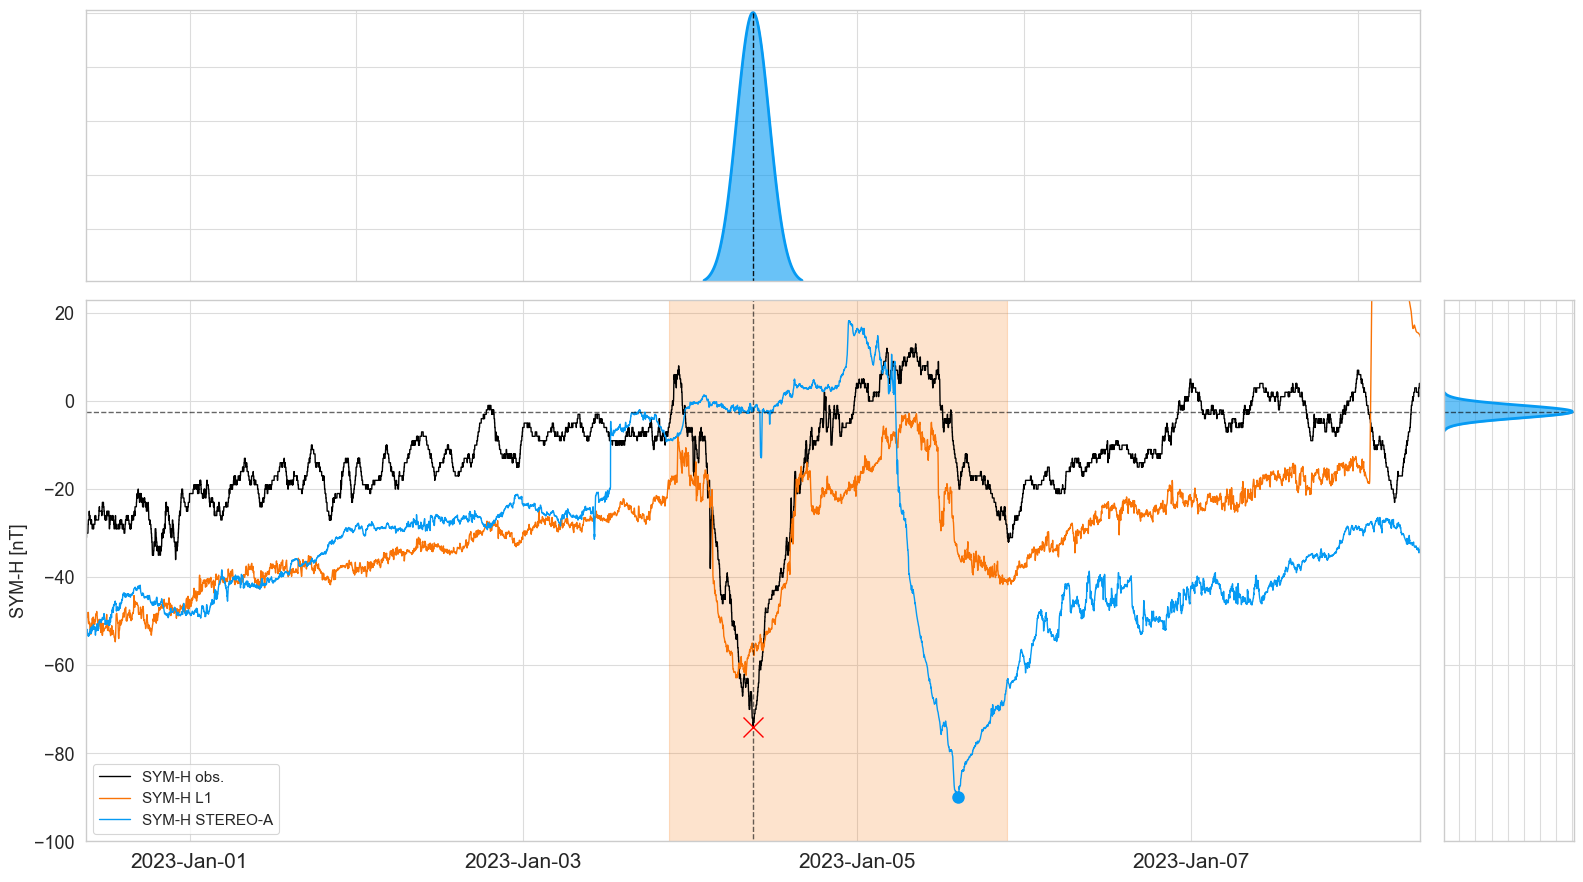

done


In [18]:

print('Save kinematics plots and overview plot for current time')

#%matplotlib inline

start_time=time.time()

#print()
#print('make animation')

#animation start time in matplotlib format

frame_time_num=mdates.date2num(t_start)#parse_time(t_start).plot_date
#frame_time = datetime(2024,3,17,10)

frame_time_num_list = [frame_time_num+k*res_in_days for k in range(k_all)]

dct_hit = [mdates.date2num(time_hit_sta[i])-frame_time_num_list for i in range(len(time_hit_sta))]

k_hit=[]

for i in dct_hit:
    k_hit.append(np.argmin(np.abs(i)))

    
dct_miss = [mdates.date2num(time_miss_omni[i])-frame_time_num_list for i in range(len(time_miss_omni))]

k_miss=[]

for i in dct_miss:
    k_miss.append(np.argmin(np.abs(i)))

#frame_index = np.where(frame_time_num_list==mdates.date2num(datetime(2024,3,18,16,0)))[0][0]

fsize=13


#for parker spiral   
theta=np.arange(0,np.deg2rad(180),0.01)

######################## make frames

#for debugging
#don't close plot in make_frame when testing

#plot_kinematics(hc_time_num1, hc_r1, hc_v1)
####################### plot and save frame with todays date and hour 
#make_frame3(k_today[0][0]) 

####################### test animation frames (different frame numbers)
#make_frame2(frame_index)#k_today[0][0])
#make_movie=True
make_frame(k_miss[2])#k_today[0][0]) #6000

for i in k_hit:
    make_frame(i, make_movie=True)

print('done') #



In [166]:

if make_movie:
    
    import multiprocessing
    import multiprocess as mp
    matplotlib.use('Agg')

    print('Creating ', k_all,' frames')

    print()

    start_time=time.time()

    #number of processes depends on your machines memory; check with command line "top"
    #how much memory is used by all your processesii
    nr_of_processes_used=1
    print('Using multiprocessing, nr of cores',multiprocessing.cpu_count(), \
          'with nr of processes used: ',nr_of_processes_used)

    #run multiprocessing pool to make all movie frames, depending only on frame number

    pool=mp.get_context('fork').Pool(processes=nr_of_processes_used)

    #pool = mp.Pool(processes=nr_of_processes_used)
    #input=[i for i in range(k_all)]
    input=[i for i in np.arange(1,k_all,1)]
    pool.map(make_frame, input)
    pool.close()
    pool.join()
    #for i in input:
     #   make_frame2(i)

    print('time in min: ',np.round((time.time()-start_time)/60))
    print('plots done, frames saved')


In [269]:
ffmpeg_path=''

os.system(ffmpeg_path+'ffmpeg -r 20 -i figures/frames/pos_anim_%05d.jpg -b 5000k \
    -r 20 figures/frames/symh_forecast.mp4 -y -loglevel warning') 

print('movie done & saved')

Please use -b:a or -b:v, -b is ambiguous


movie done & saved
